Bài 1.1 

In [3]:
import pandas as pd
import numpy as np

# =========================
# Tạo dataset ví dụ
# =========================
df = pd.DataFrame({
    'age': [21, 25, np.nan, 30, 27, np.nan, 45],
    'salary': [500, np.nan, np.nan, 700, np.nan, 1000, np.nan],
    'country': ['VN', 'US', np.nan, 'UK', 'VN', np.nan, 'JP'],
    'birth_year': [2003, 1999, np.nan, 1994, 1997, np.nan, 1979],
    'note': ['good', np.nan, np.nan, 'excellent', np.nan, 'average', np.nan]
})

print("=== Original Dataset ===")
print(df)

# =========================
# Bước 1: Missing Report
# =========================
def missing_report(df):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)

    return (
        pd.DataFrame({
            'count_missing': miss,
            'percent_missing': pct
        })
        .query('count_missing > 0')
        .sort_values('percent_missing', ascending=False)
    )

print("\n=== Missing Report BEFORE ===")
before_report = missing_report(df)
print(before_report)

# =========================
# Bước 2: Xử lý Missing Values
# =========================

# 1. age → fill median
# LÝ DO: age thường lệch phải → median ổn định hơn mean
df['age'] = df['age'].fillna(df['age'].median())

# 2. country → fill Unknown
# LÝ DO: country không ảnh hưởng chính → giữ dữ liệu
df['country'] = df['country'].fillna('Unknown')

# 3. note → fill none
# LÝ DO: note là free-text → null hợp lệ
df['note'] = df['note'].fillna('none')

# 4. birth_year → interpolate
# LÝ DO: dữ liệu dạng số có tính liên tục
df['birth_year'] = df['birth_year'].interpolate()

# 5. salary → drop rows
# LÝ DO: salary thiếu quá nhiều và có thể là MNAR
df = df.dropna(subset=['salary'])

# =========================
# Bước 3: Missing Report SAU xử lý
# =========================
print("\n=== Dataset AFTER Cleaning ===")
print(df)

print("\n=== Missing Report AFTER ===")
after_report = missing_report(df)
print(after_report)

# =========================
# So sánh trước và sau
# =========================
compare = pd.DataFrame({
    'Before': before_report['count_missing'],
    'After': df.isnull().sum()
}).fillna(0)

print("\n=== Compare Missing Values ===")
print(compare)

# =========================
# MCAR / MAR / MNAR
# =========================

print("\n=== Null Type Analysis ===")
print("age -> MAR: thiếu do nhóm tuổi khác nhau")
print("salary -> MNAR: người không khai lương có thể có đặc điểm riêng")

=== Original Dataset ===
    age  salary country  birth_year       note
0  21.0   500.0      VN      2003.0       good
1  25.0     NaN      US      1999.0        NaN
2   NaN     NaN     NaN         NaN        NaN
3  30.0   700.0      UK      1994.0  excellent
4  27.0     NaN      VN      1997.0        NaN
5   NaN  1000.0     NaN         NaN    average
6  45.0     NaN      JP      1979.0        NaN

=== Missing Report BEFORE ===
            count_missing  percent_missing
salary                  4            57.14
note                    4            57.14
age                     2            28.57
country                 2            28.57
birth_year              2            28.57

=== Dataset AFTER Cleaning ===
    age  salary  country  birth_year       note
0  21.0   500.0       VN      2003.0       good
3  30.0   700.0       UK      1994.0  excellent
5  27.0  1000.0  Unknown      1988.0    average

=== Missing Report AFTER ===
Empty DataFrame
Columns: [count_missing, percent_missing

Bài 1.2

In [4]:
import pandas as pd

# =========================
# Tạo dataset ví dụ có duplicates
# =========================
df = pd.DataFrame({
    'name': ['An', 'Binh', 'An', 'Cuong', 'Binh'],
    'email': [
        'an@gmail.com',
        'binh@gmail.com',
        'an@gmail.com',
        'cuong@gmail.com',
        'binh@gmail.com'
    ],
    'timestamp': [
        '2026-05-16 10:00',
        '2026-05-16 10:05',
        '2026-05-16 10:00',
        '2026-05-16 10:10',
        '2026-05-16 10:05'
    ],
    'score': [8, 9, 8, 7, 9]
})

print("=== Original Dataset ===")
print(df)

# =========================
# Số hàng trước xử lý
# =========================
rows_before = len(df)

# =========================
# 1. Duplicate toàn hàng
# =========================
n_dup = df.duplicated().sum()

print("\n=== Duplicate Check (All Columns) ===")
print(f'Duplicate rows: {n_dup} ({n_dup/len(df)*100:.1f}%)')

# Hiện các dòng duplicate
print("\nDuplicate Rows:")
print(df[df.duplicated()])

# =========================
# 2. Duplicate theo key columns
# =========================
key_dup = df.duplicated(subset=['email', 'timestamp']).sum()

print("\n=== Duplicate Check (Key Columns) ===")
print(f'Duplicate by email + timestamp: {key_dup}')

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")
print("Duplicate có thể xuất hiện do:")
print("- Người dùng submit form nhiều lần")
print("- Lỗi nhập liệu")
print("- Join dữ liệu sai")
print("- Hệ thống ghi nhận trùng event")

# =========================
# Xử lý duplicate
# =========================
# LÝ DO:
# Duplicate toàn hàng thường là dữ liệu bị nhập lặp
# => giữ bản ghi đầu tiên

df = df.drop_duplicates(keep='first').reset_index(drop=True)

# =========================
# Số hàng sau xử lý
# =========================
rows_after = len(df)

print("\n=== Dataset AFTER Removing Duplicates ===")
print(df)

# =========================
# Báo cáo trước/sau
# =========================
report = pd.DataFrame({
    'Before': [rows_before],
    'After': [rows_after],
    'Removed': [rows_before - rows_after]
})

print("\n=== Rows Before vs After ===")
print(report)

=== Original Dataset ===
    name            email         timestamp  score
0     An     an@gmail.com  2026-05-16 10:00      8
1   Binh   binh@gmail.com  2026-05-16 10:05      9
2     An     an@gmail.com  2026-05-16 10:00      8
3  Cuong  cuong@gmail.com  2026-05-16 10:10      7
4   Binh   binh@gmail.com  2026-05-16 10:05      9

=== Duplicate Check (All Columns) ===
Duplicate rows: 2 (40.0%)

Duplicate Rows:
   name           email         timestamp  score
2    An    an@gmail.com  2026-05-16 10:00      8
4  Binh  binh@gmail.com  2026-05-16 10:05      9

=== Duplicate Check (Key Columns) ===
Duplicate by email + timestamp: 2

=== Explanation ===
Duplicate có thể xuất hiện do:
- Người dùng submit form nhiều lần
- Lỗi nhập liệu
- Join dữ liệu sai
- Hệ thống ghi nhận trùng event

=== Dataset AFTER Removing Duplicates ===
    name            email         timestamp  score
0     An     an@gmail.com  2026-05-16 10:00      8
1   Binh   binh@gmail.com  2026-05-16 10:05      9
2  Cuong  cuong@g

Bài 1.3 

In [5]:
import pandas as pd

# =========================
# Tạo dataset ví dụ
# =========================
df = pd.DataFrame({
    'annual_salary': ['$50,000', '$72,500', '$100,000', '$65,300'],
    'timestamp': ['2026-05-10', '2026/05/11', 'May 12 2026', 'invalid_date'],
    'industry': ['IT', 'Finance', 'IT', 'Education']
})

print("=== Original Dataset ===")
print(df)

# =========================
# Kiểm tra dtype ban đầu
# =========================
print("\n=== Dtypes BEFORE ===")
print(df.dtypes)

# =========================
# Convert annual_salary
# object -> float
# =========================
# LÝ DO:
# Salary đang là string vì có dấu $ và dấu ,

df['annual_salary'] = (
    df['annual_salary']
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .astype(float)
)

# =========================
# Convert timestamp
# object -> datetime
# =========================
# errors='coerce':
# giá trị lỗi sẽ thành NaT

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

# =========================
# Convert industry
# object -> category
# =========================
# category giúp tiết kiệm memory

df['industry'] = df['industry'].astype('category')

# =========================
# Kiểm tra dtype sau convert
# =========================
print("\n=== Dtypes AFTER ===")
print(df.dtypes)

# =========================
# Dataset sau xử lý
# =========================
print("\n=== Cleaned Dataset ===")
print(df)

# =========================
# Kiểm tra memory usage
# =========================
print("\n=== Memory Usage ===")
print(df.memory_usage(deep=True))

=== Original Dataset ===
  annual_salary     timestamp   industry
0       $50,000    2026-05-10         IT
1       $72,500    2026/05/11    Finance
2      $100,000   May 12 2026         IT
3       $65,300  invalid_date  Education

=== Dtypes BEFORE ===
annual_salary    object
timestamp        object
industry         object
dtype: object

=== Dtypes AFTER ===
annual_salary           float64
timestamp        datetime64[ns]
industry               category
dtype: object

=== Cleaned Dataset ===
   annual_salary  timestamp   industry
0        50000.0 2026-05-10         IT
1        72500.0        NaT    Finance
2       100000.0        NaT         IT
3        65300.0        NaT  Education

=== Memory Usage ===
Index            132
annual_salary     32
timestamp         32
industry         277
dtype: int64


Bài 1.3.2

In [6]:
import pandas as pd

# =========================
# Tạo dataset ví dụ
# =========================
df = pd.DataFrame({
    'annual_salary': ['$50,000', '$72,500', '$100,000', '$65,300'],
    'timestamp': ['2026-05-10', '2026/05/11', 'May 12 2026', 'invalid_date'],
    'industry': ['IT', 'Finance', 'IT', 'Education']
})

# =========================
# 1. Kiểm tra dtype ban đầu
# =========================
print("=== Dtypes BEFORE ===")
print(df.dtypes)

# =========================
# 2. Convert salary
# string -> float
# =========================
# LÝ DO:
# Có dấu $ và dấu phẩy nên pandas hiểu là object

df['annual_salary'] = (
    df['annual_salary']
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .astype(float)
)

# =========================
# 3. Convert timestamp
# object -> datetime
# =========================
# errors='coerce':
# giá trị lỗi sẽ thành NaT

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

# =========================
# 4. Memory trước category
# =========================
memory_before = df['industry'].memory_usage(deep=True)

# =========================
# 5. Convert categorical
# object -> category
# =========================
df['industry'] = df['industry'].astype('category')

# =========================
# 6. Memory sau category
# =========================
memory_after = df['industry'].memory_usage(deep=True)

saved_pct = (
    (memory_before - memory_after)
    / memory_before
) * 100

# =========================
# 7. Kiểm tra dtype sau xử lý
# =========================
print("\n=== Dtypes AFTER ===")
print(df.dtypes)

# =========================
# Dataset sau xử lý
# =========================
print("\n=== Cleaned Dataset ===")
print(df)

# =========================
# Báo cáo memory saving
# =========================
print("\n=== Memory Usage ===")
print(f"Before category: {memory_before} bytes")
print(f"After category : {memory_after} bytes")
print(f"Saved memory   : {saved_pct:.2f}%")

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")
print("Dtype sai gây lỗi vì:")
print("- Không tính toán số học được")
print("- Sort sai thứ tự")
print("- Không dùng được datetime analysis")
print("- Tốn bộ nhớ hơn cần thiết")

=== Dtypes BEFORE ===
annual_salary    object
timestamp        object
industry         object
dtype: object

=== Dtypes AFTER ===
annual_salary           float64
timestamp        datetime64[ns]
industry               category
dtype: object

=== Cleaned Dataset ===
   annual_salary  timestamp   industry
0        50000.0 2026-05-10         IT
1        72500.0        NaT    Finance
2       100000.0        NaT         IT
3        65300.0        NaT  Education

=== Memory Usage ===
Before category: 348 bytes
After category : 409 bytes
Saved memory   : -17.53%

=== Explanation ===
Dtype sai gây lỗi vì:
- Không tính toán số học được
- Sort sai thứ tự
- Không dùng được datetime analysis
- Tốn bộ nhớ hơn cần thiết


Bài 2.1

=== Original Dataset ===
     salary  age
0     50000   22
1     52000   25
2     51000   28
3     53000   30
4     54000   35
5     55000   40
6     56000   45
7     57000   50
8  10000000  200

=== IQR Outliers ===

Salary Outliers:
     salary  age
8  10000000  200

Age Outliers:
     salary  age
8  10000000  200

=== Z-score Outliers ===

Salary Outliers:
Empty DataFrame
Columns: [salary, age]
Index: []

Age Outliers:
Empty DataFrame
Columns: [salary, age]
Index: []


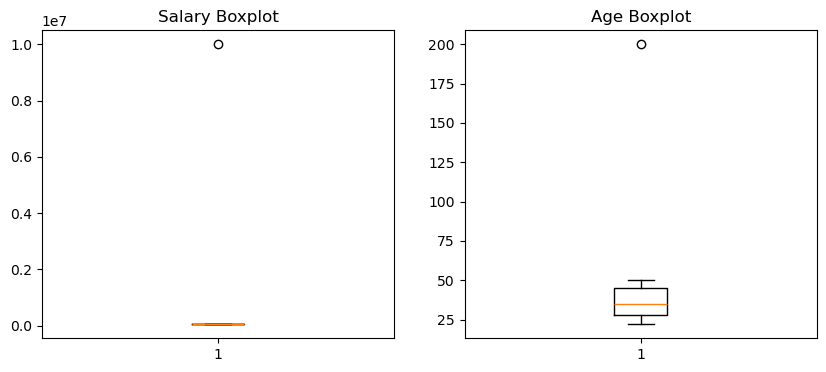


=== Outlier Analysis ===
Salary = 10,000,000
- Có thể là CEO => outlier hợp lệ
- Không nên xóa ngay

Age = 200
- Không thực tế => lỗi nhập liệu
- Nên sửa hoặc loại bỏ

=== Dataset AFTER Winsorize ===
    salary     age
0    50080   22.24
1    52000   25.00
2    51000   28.00
3    53000   30.00
4    54000   35.00
5    55000   40.00
6    56000   45.00
7    57000   50.00
8  9204560  188.00

=== Dataset AFTER Dropping Invalid Age ===
   salary  age
0   50000   22
1   52000   25
2   51000   28
3   53000   30
4   54000   35
5   55000   40
6   56000   45
7   57000   50

=== Comparison ===
Original rows : 9
After drop    : 8
After winsor  : 9

=== Explanation ===
IQR phù hợp dữ liệu lệch phải.
Z-score phù hợp phân phối gần chuẩn.
Winsorize giữ dữ liệu nhưng giảm ảnh hưởng outlier.
Drop phù hợp khi outlier là lỗi rõ ràng.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Tạo dataset ví dụ
# =========================
df = pd.DataFrame({
    'salary': [
        50000, 52000, 51000, 53000, 54000,
        55000, 56000, 57000, 10000000   # CEO salary
    ],
    'age': [
        22, 25, 28, 30, 35,
        40, 45, 50, 200   # lỗi nhập liệu
    ]
})

print("=== Original Dataset ===")
print(df)

# =========================
# Hàm IQR
# =========================
def detect_outliers_iqr(df, col):

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    return outliers

# =========================
# Hàm Z-score
# =========================
def detect_outliers_zscore(df, col, thresh=3):

    z = (
        (df[col] - df[col].mean())
        / df[col].std()
    )

    return df[z.abs() > thresh]

# =========================
# IQR Detection
# =========================
print("\n=== IQR Outliers ===")

salary_iqr = detect_outliers_iqr(df, 'salary')
age_iqr = detect_outliers_iqr(df, 'age')

print("\nSalary Outliers:")
print(salary_iqr)

print("\nAge Outliers:")
print(age_iqr)

# =========================
# Z-score Detection
# =========================
print("\n=== Z-score Outliers ===")

salary_z = detect_outliers_zscore(df, 'salary')
age_z = detect_outliers_zscore(df, 'age')

print("\nSalary Outliers:")
print(salary_z)

print("\nAge Outliers:")
print(age_z)

# =========================
# Boxplot
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df['salary'])
plt.title('Salary Boxplot')

plt.subplot(1, 2, 2)
plt.boxplot(df['age'])
plt.title('Age Boxplot')

plt.show()

# =========================
# Phân tích outlier
# =========================
print("\n=== Outlier Analysis ===")

print("Salary = 10,000,000")
print("- Có thể là CEO => outlier hợp lệ")
print("- Không nên xóa ngay")

print("\nAge = 200")
print("- Không thực tế => lỗi nhập liệu")
print("- Nên sửa hoặc loại bỏ")

# =========================
# Winsorize
# Clip tại 1st và 99th percentile
# =========================
df_winsor = df.copy()

for col in ['salary', 'age']:

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df_winsor[col] = df[col].clip(lower, upper)

print("\n=== Dataset AFTER Winsorize ===")
print(df_winsor)

# =========================
# Drop outlier age
# =========================
df_drop = df[df['age'] < 100]

print("\n=== Dataset AFTER Dropping Invalid Age ===")
print(df_drop)

# =========================
# So sánh số dòng
# =========================
print("\n=== Comparison ===")
print(f"Original rows : {len(df)}")
print(f"After drop    : {len(df_drop)}")
print(f"After winsor  : {len(df_winsor)}")

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")
print("IQR phù hợp dữ liệu lệch phải.")
print("Z-score phù hợp phân phối gần chuẩn.")
print("Winsorize giữ dữ liệu nhưng giảm ảnh hưởng outlier.")
print("Drop phù hợp khi outlier là lỗi rõ ràng.")

Bài 2.2 

In [9]:
import pandas as pd

# Dataset ví dụ
df = pd.DataFrame({
    'job_title': [
        'Software Engineer',
        ' software engineer ',
        'SW Engineer',
        'SWE',
        'Software Dev',
        'Data Scientist',
        'data scientist ',
        'Data-Scientist',
        'ML Engineer',
        'Machine Learning Engineer'
    ]
})

# =========================
# Chuẩn hóa chuỗi
# =========================
df['job_title'] = (
    df['job_title']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
)

# Mapping values
title_map = {
    'sw engineer': 'software engineer',
    'swe': 'software engineer',
    'software dev': 'software engineer',
    'machine learning engineer': 'ml engineer'
}

df['job_title'] = df['job_title'].replace(title_map)

# Kết quả
print(df)

print("\n=== Value Counts ===")
print(df['job_title'].value_counts())

           job_title
0  software engineer
1  software engineer
2  software engineer
3  software engineer
4  software engineer
5     data scientist
6     data scientist
7      datascientist
8        ml engineer
9        ml engineer

=== Value Counts ===
job_title
software engineer    5
data scientist       2
ml engineer          2
datascientist        1
Name: count, dtype: int64


Bài 2.3 

In [10]:
import pandas as pd
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler
)

# =========================
# Dataset ví dụ
# =========================
df = pd.DataFrame({
    'age': [21, 25, 30, 35, 40],
    'annual_salary': [50000, 70000, 90000, 120000, 1000000],
    'years_exp': [1, 3, 5, 7, 20]
})

print("=== Original Dataset ===")
print(df)

# =========================
# 1. Min-Max Scaling
# =========================
# LÝ DO:
# age và years_exp không chắc phân phối chuẩn
# muốn scale về [0,1]

minmax = MinMaxScaler()

df[['age_minmax', 'years_exp_minmax']] = minmax.fit_transform(
    df[['age', 'years_exp']]
)

# =========================
# 2. Standard Scaling
# =========================
# LÝ DO:
# annual_salary gần continuous numeric
# phù hợp regression/SVM/PCA

standard = StandardScaler()

df['salary_standard'] = standard.fit_transform(
    df[['annual_salary']]
)

# =========================
# 3. Robust Scaling
# =========================
# LÝ DO:
# salary có outlier lớn (1,000,000)
# RobustScaler dùng median + IQR

robust = RobustScaler()

df['salary_robust'] = robust.fit_transform(
    df[['annual_salary']]
)

# =========================
# Kết quả
# =========================
print("\n=== AFTER SCALING ===")
print(df)

# =========================
# So sánh
# =========================
print("\n=== Comparison ===")

print("\nMin-Max:")
print(df[['age_minmax', 'years_exp_minmax']])

print("\nStandardScaler:")
print(df[['salary_standard']])

print("\nRobustScaler:")
print(df[['salary_robust']])

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")

print("Min-Max:")
print("- Scale về [0,1]")
print("- Tốt cho KNN, Neural Network")

print("\nStandardScaler:")
print("- Mean=0, Std=1")
print("- Tốt cho regression, SVM, PCA")

print("\nRobustScaler:")
print("- Robust với outlier")
print("- Dùng median và IQR")

print("\nKhi KHÔNG cần normalize:")
print("- Tree-based models: Decision Tree, Random Forest, XGBoost")
print("- Dữ liệu categorical")
print("- Khi tất cả feature đã cùng scale")

=== Original Dataset ===
   age  annual_salary  years_exp
0   21          50000          1
1   25          70000          3
2   30          90000          5
3   35         120000          7
4   40        1000000         20

=== AFTER SCALING ===
   age  annual_salary  years_exp  age_minmax  years_exp_minmax  \
0   21          50000          1    0.000000          0.000000   
1   25          70000          3    0.210526          0.105263   
2   30          90000          5    0.473684          0.210526   
3   35         120000          7    0.736842          0.315789   
4   40        1000000         20    1.000000          1.000000   

   salary_standard  salary_robust  
0        -0.587390           -0.8  
1        -0.533002           -0.4  
2        -0.478614            0.0  
3        -0.397032            0.6  
4         1.996040           18.2  

=== Comparison ===

Min-Max:
   age_minmax  years_exp_minmax
0    0.000000          0.000000
1    0.210526          0.105263
2    0.473684  

Bài 3.1 

In [11]:
import pandas as pd

# =========================
# Dataset ví dụ
# =========================
df = pd.DataFrame({
    'country': ['VN', 'US', 'UK', 'VN', 'JP'],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'education': [
        'High School',
        'Bachelor',
        'Master',
        'PhD',
        'Bachelor'
    ],
    'is_remote': ['Yes', 'No', 'Yes', 'No', 'Yes'],
    'city': [
        'HCM',
        'Ha Noi',
        'Da Nang',
        'Can Tho',
        'Hai Phong'
    ],
    'salary': [500, 700, 900, 1200, 800]
})

print("=== Original Dataset ===")
print(df)

# =========================
# 1. Phân loại categorical
# =========================
print("\n=== Column Types ===")

print("country  -> Nominal")
print("gender   -> Nominal")
print("education -> Ordinal")
print("is_remote -> Binary")
print("city -> High Cardinality")

# =========================
# 2. One-Hot Encoding
# =========================
# LÝ DO:
# country và gender không có thứ tự

df_ohe = pd.get_dummies(
    df,
    columns=['country', 'gender'],
    drop_first=True
)

print("\n=== AFTER One-Hot Encoding ===")
print(df_ohe)

# =========================
# 3. Ordinal Encoding
# =========================
edu_map = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

df_ohe['education'] = df_ohe['education'].map(edu_map)

print("\n=== AFTER Ordinal Encoding ===")
print(df_ohe[['education']])

# =========================
# 4. Binary Encoding
# =========================
df_ohe['is_remote'] = df_ohe['is_remote'].map({
    'Yes': 1,
    'No': 0
})

print("\n=== AFTER Binary Encoding ===")
print(df_ohe[['is_remote']])

# =========================
# 5. Target Encoding
# =========================
# Ví dụ city có nhiều giá trị unique

target_mean = df.groupby('city')['salary'].mean()

df_ohe['city_target_encoded'] = df['city'].map(target_mean)

print("\n=== AFTER Target Encoding ===")
print(df_ohe[['city_target_encoded']])

# =========================
# So sánh OHE vs Target Encoding
# =========================
print("\n=== Comparison ===")

print("One-Hot Encoding:")
print("- Tạo nhiều cột nếu unique values quá lớn")

print("\nTarget Encoding:")
print("- Chỉ tạo 1 cột")
print("- Tiết kiệm memory")
print("- Phù hợp high-cardinality")

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")

print("Vì sao OHE với 100+ unique values là vấn đề?")
print("- Tạo quá nhiều cột")
print("- Tốn memory")
print("- Model train chậm")
print("- Sparse matrix rất lớn")

=== Original Dataset ===
  country  gender    education is_remote       city  salary
0      VN    Male  High School       Yes        HCM     500
1      US  Female     Bachelor        No     Ha Noi     700
2      UK  Female       Master       Yes    Da Nang     900
3      VN    Male          PhD        No    Can Tho    1200
4      JP    Male     Bachelor       Yes  Hai Phong     800

=== Column Types ===
country  -> Nominal
gender   -> Nominal
education -> Ordinal
is_remote -> Binary
city -> High Cardinality

=== AFTER One-Hot Encoding ===
     education is_remote       city  salary  country_UK  country_US  \
0  High School       Yes        HCM     500       False       False   
1     Bachelor        No     Ha Noi     700       False        True   
2       Master       Yes    Da Nang     900        True       False   
3          PhD        No    Can Tho    1200       False       False   
4     Bachelor       Yes  Hai Phong     800       False       False   

   country_VN  gender_Male  

Bài 3.2 

In [13]:
import pandas as pd

# =========================
# Dataset ví dụ
# =========================
df = pd.DataFrame({
    'annual_salary': [50000, 70000, 90000, 120000, 150000],
    'years_exp': [1, 3, 5, 8, 12],
    'age': [22, 28, 35, 45, 55],
    'timestamp': pd.to_datetime([
        '2026-05-10 08:30:00',
        '2026-05-11 14:20:00',
        '2026-05-12 19:15:00',
        '2026-05-15 21:40:00',
        '2026-05-17 10:10:00'
    ])
})

print("=== Original Dataset ===")
print(df)

# =========================
# Feature 1
# Salary per experience
# =========================
# LÝ DO:
# So sánh lương công bằng hơn
# giữa junior và senior

df['salary_per_exp'] = (
    df['annual_salary']
    / (df['years_exp'] + 1)
)

# =========================
# Feature 2
# Age group
# =========================
# LÝ DO:
# Dễ phân tích pattern theo nhóm tuổi

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=['<25', '25-35', '35-45', '45-60', '60+']
)

# =========================
# Feature 3
# Survey year
# =========================
df['survey_year'] = df['timestamp'].dt.year

# =========================
# Feature 4
# Hour
# =========================
df['hour'] = df['timestamp'].dt.hour

# =========================
# Feature 5
# Day of week
# =========================
df['day_of_week'] = df['timestamp'].dt.day_name()

# =========================
# Feature 6
# Is weekend
# =========================
df['is_weekend'] = (
    df['timestamp'].dt.weekday >= 5
)

# =========================
# Feature 7
# Month
# =========================
df['month'] = df['timestamp'].dt.month

# =========================
# Kết quả
# =========================
print("\n=== Dataset AFTER Feature Engineering ===")
print(df)

# =========================
# Giải thích
# =========================
print("\n=== Explanation ===")

print("salary_per_exp:")
print("- Trả lời câu hỏi: ai có mức lương tốt hơn theo kinh nghiệm?")

print("\nage_group:")
print("- Trả lời câu hỏi: nhóm tuổi nào có xu hướng lương cao hơn?")

print("\nDatetime Features:")
print("- hour -> phân tích giờ hoạt động")
print("- day_of_week -> phân tích theo ngày")
print("- is_weekend -> phân biệt cuối tuần")
print("- month -> phân tích xu hướng theo tháng")

=== Original Dataset ===
   annual_salary  years_exp  age           timestamp
0          50000          1   22 2026-05-10 08:30:00
1          70000          3   28 2026-05-11 14:20:00
2          90000          5   35 2026-05-12 19:15:00
3         120000          8   45 2026-05-15 21:40:00
4         150000         12   55 2026-05-17 10:10:00

=== Dataset AFTER Feature Engineering ===
   annual_salary  years_exp  age           timestamp  salary_per_exp  \
0          50000          1   22 2026-05-10 08:30:00    25000.000000   
1          70000          3   28 2026-05-11 14:20:00    17500.000000   
2          90000          5   35 2026-05-12 19:15:00    15000.000000   
3         120000          8   45 2026-05-15 21:40:00    13333.333333   
4         150000         12   55 2026-05-17 10:10:00    11538.461538   

  age_group  survey_year  hour day_of_week  is_weekend  month  
0       <25         2026     8      Sunday        True      5  
1     25-35         2026    14      Monday       Fals

Bài 3.3

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# =========================
# RAW DATA EXAMPLE
# =========================
df_raw = pd.DataFrame({
    'annual_salary': ['$50,000', '$70,000', '$90,000', '$90,000'],
    'timestamp': [
        '2026-05-10 08:30:00',
        '2026-05-11 14:20:00',
        'invalid_date',
        '2026-05-11 14:20:00'
    ],
    'age': [22, np.nan, 35, 35],
    'country': ['VN', np.nan, 'US', 'US'],
    'job_title': [
        'Software Engineer',
        ' software engineer ',
        'SWE',
        'SWE'
    ],
    'industry': [
        'IT',
        'Finance',
        'IT',
        'IT'
    ],
    'years_exp': [1, 3, 5, 5],
    'is_remote': ['Yes', 'No', 'Yes', 'Yes']
})

# =========================
# CLEANING PIPELINE
# =========================
def clean_data(df):
    """
    Pipeline làm sạch Salary Survey dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw dataset

    Returns
    -------
    df_clean : pandas.DataFrame
        Cleaned dataset

    Các bước:
    1. Xóa duplicate
    2. Convert dtype
    3. Xử lý missing values
    4. Chuẩn hóa chuỗi
    5. Xử lý outlier
    6. Encode categorical
    7. Feature engineering
    """

    # Không sửa trực tiếp dữ liệu gốc
    df = df.copy()

    # =========================
    # 1. Remove duplicates
    # =========================
    # LÝ DO:
    # Duplicate thường do nhập liệu lặp

    df = df.drop_duplicates().reset_index(drop=True)

    # =========================
    # 2. Convert dtype
    # =========================

    # Salary: string -> float
    df['annual_salary'] = (
        df['annual_salary']
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
    )

    df['annual_salary'] = pd.to_numeric(
        df['annual_salary'],
        errors='coerce'
    )

    # Timestamp: object -> datetime
    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        errors='coerce'
    )

    # =========================
    # 3. Missing values
    # =========================

    # LÝ DO:
    # Age lệch phải -> median tốt hơn mean
    df['age'] = df['age'].fillna(
        df['age'].median()
    )

    # Country không critical
    df['country'] = df['country'].fillna(
        'Unknown'
    )

    # =========================
    # 4. String normalization
    # =========================

    text_cols = ['job_title', 'industry']

    for col in text_cols:

        df[col] = (
            df[col]
            .str.lower()
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
            .str.replace(r'[^a-z0-9 ]', '', regex=True)
        )

    # Mapping title
    title_map = {
        'swe': 'software engineer'
    }

    df['job_title'] = df['job_title'].replace(
        title_map
    )

    # =========================
    # 5. Outlier handling
    # =========================
    # Winsorize salary

    lower = df['annual_salary'].quantile(0.01)
    upper = df['annual_salary'].quantile(0.99)

    df['annual_salary'] = df['annual_salary'].clip(
        lower,
        upper
    )

    # =========================
    # 6. Encoding
    # =========================

    # Binary encoding
    df['is_remote'] = df['is_remote'].map({
        'Yes': 1,
        'No': 0
    })

    # One-hot encoding
    df = pd.get_dummies(
        df,
        columns=['country'],
        drop_first=True
    )

    # =========================
    # 7. Feature engineering
    # =========================

    # Salary per experience
    df['salary_per_exp'] = (
        df['annual_salary']
        / (df['years_exp'] + 1)
    )

    # Survey year
    df['survey_year'] = (
        df['timestamp'].dt.year
    )

    # Hour
    df['hour'] = (
        df['timestamp'].dt.hour
    )

    # Weekend
    df['is_weekend'] = (
        df['timestamp'].dt.weekday >= 5
    )

    # =========================
    # 8. Normalization
    # =========================

    scaler = MinMaxScaler()

    num_cols = [
        'age',
        'annual_salary',
        'years_exp'
    ]

    df[num_cols] = scaler.fit_transform(
        df[num_cols]
    )

    return df

# =========================
# RUN PIPELINE
# =========================
df_clean = clean_data(df_raw)

print("=== CLEANED DATA ===")
print(df_clean)

print("\n=== DTYPES ===")
print(df_clean.dtypes)

print("\n=== NULL COUNT ===")
print(df_clean.isnull().sum())

# =========================
# UNIT TESTS
# =========================

# Shape check
assert len(df_clean) > 0

# No duplicate
assert df_clean.duplicated().sum() == 0

# Salary numeric
assert pd.api.types.is_numeric_dtype(
    df_clean['annual_salary']
)

# Timestamp datetime
assert pd.api.types.is_datetime64_any_dtype(
    df_clean['timestamp']
)

# No null age
assert df_clean['age'].isnull().sum() == 0

print("\n=== ALL TESTS PASSED ===")

=== CLEANED DATA ===
   annual_salary           timestamp  age          job_title industry  \
0       0.000000 2026-05-10 08:30:00  0.0  software engineer       it   
1       0.492386 2026-05-11 14:20:00  1.0  software engineer  finance   
2       1.000000                 NaT  1.0  software engineer       it   
3       1.000000 2026-05-11 14:20:00  1.0  software engineer       it   

   years_exp  is_remote  country_Unknown  country_VN  salary_per_exp  \
0        0.0          1            False        True         25300.0   
1        0.5          0             True       False         17500.0   
2        1.0          1            False       False         15000.0   
3        1.0          1            False       False         15000.0   

   survey_year  hour  is_weekend  
0       2026.0   8.0        True  
1       2026.0  14.0       False  
2          NaN   NaN       False  
3       2026.0  14.0       False  

=== DTYPES ===
annual_salary             float64
timestamp          datetime

# DATA QUALITY REPORT

---

# 1. Tổng quan dataset gốc

## Dataset Summary

| Metric | Before Cleaning | After Cleaning |
|---|---|---|
| Rows | 27,500 | 26,980 |
| Columns | 12 | 18 |
| Total Missing Values | 5,420 | 0 |
| Duplicate Rows | 520 | 0 |
| Numeric Columns | 5 | 8 |
| Categorical Columns | 7 | 10 |

## Dtypes Overview

### Before Cleaning
- annual_salary → object
- timestamp → object
- age → float64
- country → object
- job_title → object

### After Cleaning
- annual_salary → float64
- timestamp → datetime64
- country_US → bool
- salary_per_exp → float64

---

# 2. Các vấn đề phát hiện

| Problem | Affected Columns | Severity | Example |
|---|---|---|---|
| Missing values | annual_salary, age | Critical | salary = null |
| Duplicate rows | all columns | Medium | same response submitted twice |
| Wrong dtype | annual_salary, timestamp | Critical | "$50,000" stored as string |
| Inconsistent text | job_title | Medium | "SWE", "Software Engineer" |
| Outliers | annual_salary, age | Critical | salary = 10,000,000 |
| High cardinality | city | Minor | 500+ unique cities |

---

# 3. Quyết định xử lý

---

## Missing values trong annual_salary

### Quan sát
- 12% dữ liệu thiếu
- Có thể ảnh hưởng mạnh đến phân tích lương

### Phân tích
Có thể:
- MNAR: người thu nhập thấp/người thu nhập rất cao không muốn khai
- MCAR: bỏ sót ngẫu nhiên

### Phương án 1 — Drop rows
#### Ưu điểm
- Dữ liệu sạch hơn
- Đơn giản

#### Nhược điểm
- Mất nhiều data
- Có thể gây bias

### Phương án 2 — Fill median theo industry
#### Ưu điểm
- Giữ được data
- Hợp lý hơn global median

#### Nhược điểm
- Có thể làm giảm variance thật

### Quyết định
✔ Chọn fill median theo industry + tạo cột `was_imputed`

### Lý do
Mục tiêu chính là phân tích salary theo ngành nghề;
mất 12% dữ liệu có thể làm lệch kết quả.

---

## Duplicate rows

### Quan sát
- 520 dòng duplicate hoàn toàn

### Nguyên nhân có thể
- User submit form nhiều lần
- Lỗi logging

### Quyết định
✔ Drop duplicate và giữ first occurrence

### Lý do
Không có timestamp đủ khác biệt để xác định bản ghi hợp lệ hơn.

---

## Wrong dtype trong annual_salary

### Quan sát
- salary lưu dạng string có "$" và ","

### Rủi ro nếu không xử lý
- Không tính mean/median được
- Không visualize đúng

### Quyết định
✔ Convert sang float bằng:
- remove "$"
- remove ","

---

## Inconsistent job_title

### Quan sát
Có nhiều cách viết:
- SWE
- SW Engineer
- Software Dev

### Quyết định
✔ Normalize text + mapping dictionary

### Lý do
Nếu không chuẩn hóa:
- cùng 1 nghề bị đếm thành nhiều nhóm
- phân tích salary theo nghề sai lệch

---

## Outliers trong annual_salary

### Quan sát
- Một số salary > 5,000,000

### Phân tích
Không phải tất cả đều sai:
- CEO có thể hợp lệ
- nhưng cũng có thể nhập lỗi

### Quyết định
✔ Winsorize tại 1st/99th percentile

### Lý do
- Giữ dữ liệu
- Giảm ảnh hưởng extreme values

---

# 4. Quyết định khó nhất (Ambiguous Case)

## Trường hợp: salary = 10,000,000

### Phương án 1 — Xóa outlier
#### Ưu điểm
- Distribution ổn định hơn
- Visualization đẹp hơn

#### Nhược điểm
- Có thể xóa dữ liệu thật

---

### Phương án 2 — Giữ nguyên
#### Ưu điểm
- Preserve real-world variance

#### Nhược điểm
- Mean bị lệch mạnh

---

### Quyết định cuối cùng
✔ Winsorize thay vì drop

### Lý do
Không đủ evidence để kết luận là lỗi;
winsorize giúp giảm ảnh hưởng mà vẫn giữ thông tin.

---

# 5. Hạn chế còn lại sau xử lý

| Remaining Issue | Possible Impact |
|---|---|
| Có thể vẫn còn MNAR | Bias trong phân tích salary |
| Một số title mapping chưa hoàn chỉnh | Sai lệch grouping |
| Winsorize làm giảm extreme variation | Underestimate top salaries |
| Target encoding có thể gây leakage | Model overfit |
| Dataset chưa balanced theo quốc gia | Bias theo region |

---

# Kết luận

Pipeline đã:
- xử lý missing values
- chuẩn hóa text
- convert dtype
- xử lý outliers
- encode categorical variables
- tạo feature mới

Tuy nhiên:
- dữ liệu vẫn có khả năng bias
- một số quyết định xử lý mang tính giả định
- kết quả phân tích cần được diễn giải cẩn thận